# Task 5

Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


Copy Structured Dataset from Drive to Colab

In [ ]:
!mkdir -p /content/data
!cp -r "/content/drive/MyDrive/AI Driven Web Application for Automated Disease Detection/dataset/structured dataset" /content/data/

Install Dependencies

In [ ]:
!pip install tensorflow numpy matplotlib keras --quiet

GPU / CPU Detection

In [ ]:
import tensorflow as tf
from tensorflow.keras import mixed_precision

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU detected:", gpus)
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        mixed_precision.set_global_policy("mixed_float16")
        print("Using GPU with mixed precision")
    except RuntimeError as e:
        print(e)
else:
    print("GPU not available — using CPU")

GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Using GPU with mixed precision


Dataset Paths & Parameters

In [ ]:
# BASE_DIR = "/content/drive/MyDrive/AI Driven Web Application for Automated Disease Detection/dataset/structured dataset"
BASE_DIR = "/content/drive/MyDrive/AI Driven Web Application for Automated Disease Detection/dataset/structured dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 4   # Use smaller batch size if GPU memory is limited

print("Base Directory:", BASE_DIR)
print(f"Image Size: {IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")

Base Directory: /content/drive/MyDrive/AI Driven Web Application for Automated Disease Detection/dataset/structured dataset
Image Size: (224, 224)
Batch Size: 4


Load Datasets

In [ ]:
import os
from PIL import Image

def find_corrupted_images(directory):
    corrupted = []
    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                path = os.path.join(root, file)
                try:
                    with Image.open(path) as img:
                        img.verify()  # just verify, no full load
                except Exception:
                    corrupted.append(path)
    return corrupted

corrupted_images = find_corrupted_images("/content/data/structured dataset")

print(f"Found {len(corrupted_images)} corrupted or unreadable image(s).")
if len(corrupted_images) > 0:
    print("\nExamples:")
    print("\n".join(corrupted_images[:10]))

Found 0 corrupted or unreadable image(s).


In [ ]:
for img_path in corrupted_images:
    try:
        os.remove(img_path)
    except Exception as e:
        print(f"Error deleting {img_path}: {e}")

print("All corrupted images removed successfully!")

All corrupted images removed successfully!


In [ ]:
# ==============================================================
# LOAD DATASETS USING image_dataset_from_directory
# --------------------------------------------------------------
# Reads images from subfolders (each folder = one class)
# Auto-assigns numeric labels based on folder names
# Resizes all images to IMG_SIZE (e.g. 224x224)
# Groups images into batches of size BATCH_SIZE
#
# Training dataset:
#   shuffle=True  -> ensures randomization for learning
#
# Validation & Test datasets:
#   shuffle=False -> ensures consistent evaluation
# ==============================================================

import os

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, "validation"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 38104 files belonging to 44 classes.
Found 9458 files belonging to 44 classes.
Found 5741 files belonging to 44 classes.


Dataset Information

In [ ]:
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Number of classes:", NUM_CLASSES)
print("\nClass names:")
for i, name in enumerate(class_names, 1):
    print(f"{i:2d}. {name}")

Number of classes: 44

Class names:
 1. Cassava___Bacterial_Blight_CBB
 2. Cassava___Brown_Streak_Disease_CBSD
 3. Cassava___Green_Mottle_CGM
 4. Cassava___Healthy
 5. Cassava___Mosaic_Disease_CMD
 6. Rice___BrownSpot
 7. Rice___Healthy
 8. Rice___Hispa
 9. Rice___LeafBlast
10. apple___apple_scab
11. apple___black_rot
12. apple___cedar_apple_rust
13. apple___healthy
14. cherry (including sour)___healthy
15. cherry (including sour)___powdery_mildew
16. corn (maize)___cercospora_leaf_spot_gray_leaf_spot
17. corn (maize)___common_rust
18. corn (maize)___healthy
19. corn (maize)___northern_leaf_blight
20. grape___black_rot
21. grape___esca_black_measles
22. grape___healthy
23. grape___leaf_blight_isariopsis_leaf_spot
24. orange___haunglongbing_citrus_greening
25. peach___bacterial_spot
26. peach___healthy
27. pepper, bell___bacterial_spot
28. pepper, bell___healthy
29. potato___early_blight
30. potato___healthy
31. potato___late_blight
32. squash___powdery_mildew
33. strawberry___healthy
3

Count Images in Each Dataset

In [ ]:
train_count = sum(1 for _ in train_ds.unbatch())
val_count = sum(1 for _ in val_ds.unbatch())
test_count = sum(1 for _ in test_ds.unbatch())

print("\nDataset Summary")
print("-" * 40)
print(f"Train images      : {train_count}")
print(f"Validation images : {val_count}")
print(f"Test images       : {test_count}")


Dataset Summary
----------------------------------------
Train images      : 38104
Validation images : 9458
Test images       : 5741


Visualize Sample Images

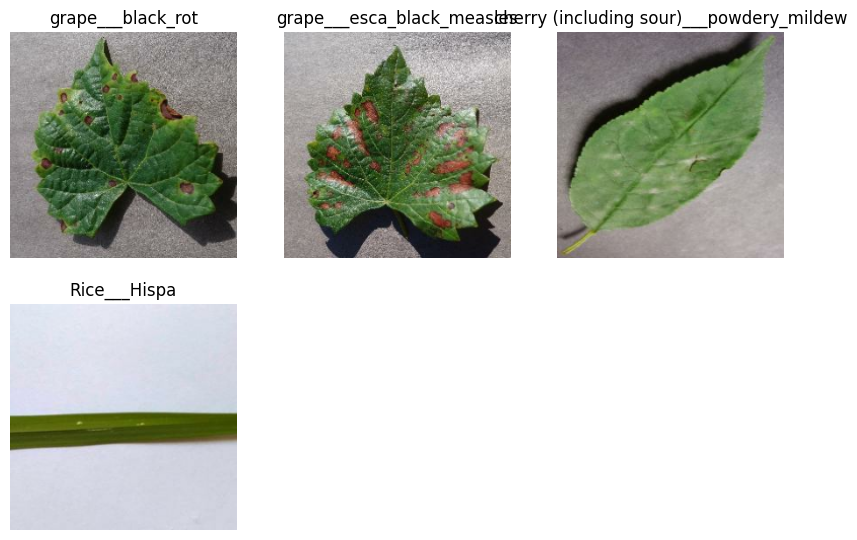

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):  # Take 1 batch
    batch_size = images.shape[0]  # actual number of images in this batch
    grid_size = min(batch_size, 9)  # max 9 images shown
    for i in range(grid_size):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

# Task 6

Prefetch Batches

In [ ]:
train_ds = train_ds.shuffle(500)
train_ds = train_ds.prefetch(1)

val_ds = val_ds.prefetch(1)
test_ds = test_ds.prefetch(1)

print("Controlled shuffle + prefetch applied")

Controlled shuffle + prefetch applied


Data Augmentation with TensorFlow

In [ ]:
from tensorflow.keras import layers, Sequential

data_augmentation = Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(factor=0.2)  # adds brightness variation
])

print("Data augmentation pipeline created.")

Data augmentation pipeline created.


Calculate Class Weights

In [ ]:
import os

TRAIN_DIR = os.path.join(BASE_DIR, "train")

class_counts = {}

for cls in sorted(os.listdir(TRAIN_DIR)):
    cls_path = os.path.join(TRAIN_DIR, cls)

    if os.path.isdir(cls_path):
        count = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])
        class_counts[cls] = count

max_count = max(class_counts.values())

class_weights = {}

print("Class weights computed (FAST)\n")

for idx, cls in enumerate(sorted(class_counts.keys())):
    weight = max_count / class_counts[cls]
    class_weights[idx] = weight

    print(f"Class {idx:2d} | {cls:<45} | "
          f"Images: {class_counts[cls]:5d} | "
          f"Weight: {weight:.2f}")

Class weights computed (FAST)

Class  0 | Cassava___Bacterial_Blight_CBB                | Images:   306 | Weight: 12.96
Class  1 | Cassava___Brown_Streak_Disease_CBSD           | Images:   372 | Weight: 10.66
Class  2 | Cassava___Green_Mottle_CGM                    | Images:   285 | Weight: 13.92
Class  3 | Cassava___Healthy                             | Images:   370 | Weight: 10.72
Class  4 | Cassava___Mosaic_Disease_CMD                  | Images:   240 | Weight: 16.52
Class  5 | Rice___BrownSpot                              | Images:   377 | Weight: 10.52
Class  6 | Rice___Healthy                                | Images:  1072 | Weight: 3.70
Class  7 | Rice___Hispa                                  | Images:   408 | Weight: 9.72
Class  8 | Rice___LeafBlast                              | Images:   562 | Weight: 7.06
Class  9 | apple___apple_scab                            | Images:   454 | Weight: 8.74
Class 10 | apple___black_rot                             | Images:   448 | Weight: 

# Task 7

Import Dependencies & Define Base Model

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.applications.efficientnet import preprocess_input
import tensorflow as tf

Declare the Base Model

In [ ]:
base_model = EfficientNetB2(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)

base_model.trainable = False

31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
inputs = layers.Input(shape=IMG_SIZE + (3,))

x = data_augmentation(inputs)
x = preprocess_input(x)

# Important: do NOT freeze here
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)

print("Model architecture built successfully")

Model architecture built successfully


In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print("GPU Memory Growth Enabled")

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU Memory Growth Enabled


In [ ]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

print("Mixed Precision Enabled")

Mixed Precision Enabled


In [ ]:
base_model.trainable = False
print("Base model frozen")

Base model frozen


Compile Model

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully")
model.summary()

Model compiled successfully


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb2 (Functional)     │ (None, 7, 7, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1408)           │         5,632 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 44)             │        61,996 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,836,197 (29.89 MB)

 Trainable params: 64,812 (253.17 KB)

 Non-trainable params: 7,771,385 (29.65 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

# Save path
drive_save_path = "/content/drive/MyDrive/AI Driven Web Application for Automated Disease Detection/models"
os.makedirs(drive_save_path, exist_ok=True)

checkpoint_path = os.path.join(drive_save_path, "efficientnetb2_leaf_model_finetuned.keras")

In [ ]:
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=False,   # saving full model (not just weights)
    verbose=1
)

print("Callbacks ready:", checkpoint_path)

Callbacks ready: /content/drive/MyDrive/AI Driven Web Application for Automated Disease Detection/models/efficientnetb2_leaf_model_finetuned.keras


In [ ]:
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/10
9526/9526 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7540 - loss: 3.9980
Epoch 1: val_accuracy improved from -inf to 0.86985, saving model to /content/drive/MyDrive/AI Driven Web Application for Automated Disease Detection/models/efficientnetb2_leaf_model_finetuned.keras
9526/9526 ━━━━━━━━━━━━━━━━━━━━ 447s 46ms/step - accuracy: 0.7540 - loss: 3.9980 - val_accuracy: 0.8698 - val_loss: 0.4178
Epoch 2/10
9525/9526 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7775 - loss: 3.6613
Epoch 2: val_accuracy improved from 0.86985 to 0.87503, saving model to /content/drive/MyDrive/AI Driven Web Application for Automated Disease Detection/models/efficientnetb2_leaf_model_finetuned.keras
9526/9526 ━━━━━━━━━━━━━━━━━━━━ 445s 46ms/step - accuracy: 0.7775 - loss: 3.6613 - val_accuracy: 0.8750 - val_loss: 0.3965
Epoch 3/10
9524/9526 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7804 - loss: 3.5595
Epoch 3: val_accuracy improved from 0.87503 to 0.88602, saving model to /content/drive/M

# Task 8

Evaluate the Model on Test Data

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Final Test Accuracy:", test_acc)

1436/1436 ━━━━━━━━━━━━━━━━━━━━ 51s 35ms/step - accuracy: 0.7629 - loss: 0.8249
Final Test Accuracy: 0.866051197052002


Plot Accuracy & Loss Graphs

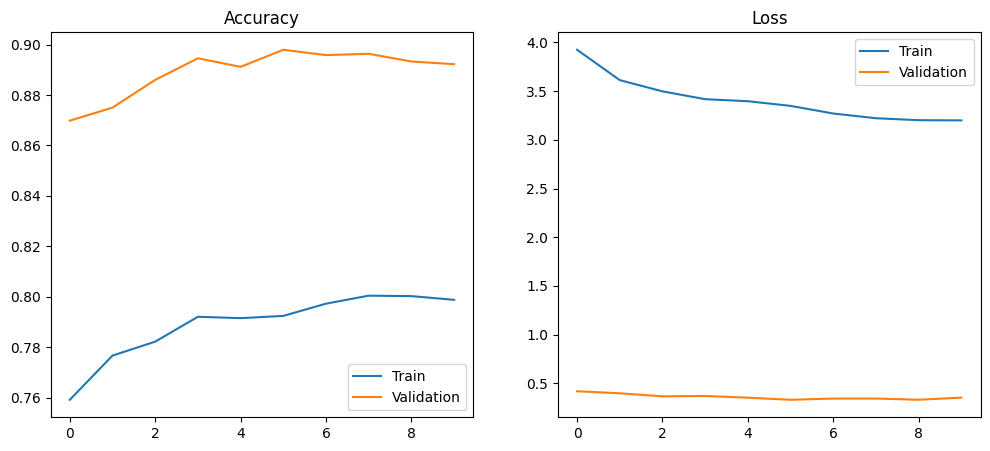

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])

plt.subplot(1,2,2)
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Validation"])

plt.show()

Optimizations - Fine Tuning (Unfreeze Top Layers)

In [ ]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [ ]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, type(layer))

0 input_layer_1 <class 'keras.src.layers.core.input_layer.InputLayer'>
1 sequential <class 'keras.src.models.sequential.Sequential'>
2 efficientnetb2 <class 'keras.src.models.functional.Functional'>
3 global_average_pooling2d <class 'keras.src.layers.pooling.global_average_pooling2d.GlobalAveragePooling2D'>
4 batch_normalization <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
5 dropout <class 'keras.src.layers.regularization.dropout.Dropout'>
6 dense <class 'keras.src.layers.core.dense.Dense'>


In [ ]:
# Get EfficientNet backbone correctly
base_model = model.get_layer("efficientnetb2")

# Unfreeze it
base_model.trainable = True

# Check total layers
total_layers = len(base_model.layers)
print("Total layers in EfficientNet:", total_layers)

# Unfreeze only last 30 layers
fine_tune_at = total_layers - 30

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print("Fine-tuning from layer:", fine_tune_at)

Total layers in EfficientNet: 340
Fine-tuning from layer: 310


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/10
9526/9526 ━━━━━━━━━━━━━━━━━━━━ 556s 55ms/step - accuracy: 0.6300 - loss: 6.2222 - val_accuracy: 0.8679 - val_loss: 0.4623
Epoch 2/10
9526/9526 ━━━━━━━━━━━━━━━━━━━━ 532s 55ms/step - accuracy: 0.7417 - loss: 4.1172 - val_accuracy: 0.8912 - val_loss: 0.3920
Epoch 3/10
9526/9526 ━━━━━━━━━━━━━━━━━━━━ 548s 57ms/step - accuracy: 0.7741 - loss: 3.5950 - val_accuracy: 0.8950 - val_loss: 0.3871
Epoch 4/10
9526/9526 ━━━━━━━━━━━━━━━━━━━━ 534s 55ms/step - accuracy: 0.7893 - loss: 3.2899 - val_accuracy: 0.9026 - val_loss: 0.3788
Epoch 5/10
9526/9526 ━━━━━━━━━━━━━━━━━━━━ 545s 56ms/step - accuracy: 0.8066 - loss: 3.0526 - val_accuracy: 0.9055 - val_loss: 0.3467
Epoch 6/10
9526/9526 ━━━━━━━━━━━━━━━━━━━━ 545s 57ms/step - accuracy: 0.8109 - loss: 2.9264 - val_accuracy: 0.9118 - val_loss: 0.3374
Epoch 7/10
9526/9526 ━━━━━━━━━━━━━━━━━━━━ 557s 56ms/step - accuracy: 0.8187 - loss: 2.7789 - val_accuracy: 0.9130 - val_loss: 0.3318
Epoch 8/10
9526/9526 ━━━━━━━━━━━━━━━━━━━━ 550s 55ms/step - accuracy: 

Final Evaluation After Optimizations

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Fine-Tuned Test Accuracy:", test_acc)

1436/1436 ━━━━━━━━━━━━━━━━━━━━ 42s 29ms/step - accuracy: 0.7686 - loss: 0.9481
Fine-Tuned Test Accuracy: 0.8827730417251587


In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Accuracy:", round(test_acc, 4))
print("Test Loss:", round(test_loss, 4))

1436/1436 ━━━━━━━━━━━━━━━━━━━━ 42s 29ms/step - accuracy: 0.7686 - loss: 0.9481
Test Accuracy: 0.8828
Test Loss: 0.444


Visualize the Final Performance

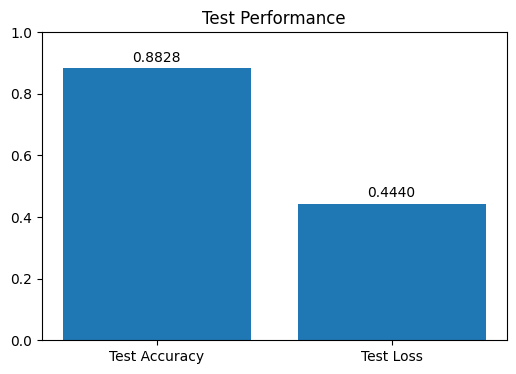

In [ ]:
import matplotlib.pyplot as plt

# Values
metrics = ['Test Accuracy', 'Test Loss']
values = [test_acc, test_loss]

plt.figure(figsize=(6,4))
bars = plt.bar(metrics, values)

plt.title("Test Performance")
plt.ylim(0, 1)

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.02,
             f'{height:.4f}',
             ha='center')

plt.show()

Save the Optimized Model

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/AI Driven Web Application for Automated Disease Detection/models/leaf_disease_efficientnet_final.keras"

model.save(MODEL_PATH)

print("Model saved successfully at:", MODEL_PATH)

Model saved successfully at: /content/drive/MyDrive/AI Driven Web Application for Automated Disease Detection/models/leaf_disease_efficientnet_final.keras


# Task 9

In [ ]:
import tensorflow as tf

MODEL_PATH = "/content/drive/MyDrive/AI Driven Web Application for Automated Disease Detection/models/leaf_disease_efficientnet_final.keras"

loaded_model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded successfully!")

Model loaded successfully!


Predicting Unseen Images

In [ ]:
import os
import random

BASE_DIR = "/content/drive/MyDrive/AI Driven Web Application for Automated Disease Detection/dataset/structured dataset"

test_dir = os.path.join(BASE_DIR, "test")

# Pick random class
random_class = random.choice(os.listdir(test_dir))

# Pick random image
random_image = random.choice(os.listdir(os.path.join(test_dir, random_class)))

img_path = os.path.join(test_dir, random_class, random_image)

print("Selected image:", img_path)

Selected image: /content/drive/MyDrive/AI Driven Web Application for Automated Disease Detection/dataset/structured dataset/test/potato___early_blight/fba7a41d-25df-4a1c-93d1-98d62e3376e0___RS_Early.B 8207.JPG


Selected Image: /content/drive/MyDrive/AI Driven Web Application for Automated Disease Detection/dataset/predict unseen images/images.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


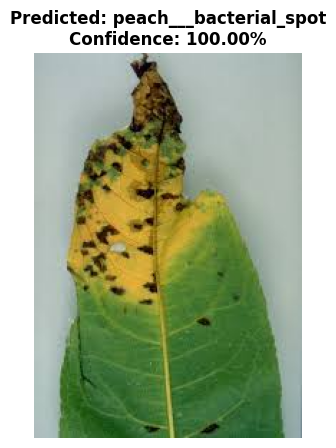


Top 5 Predictions:
1. peach___bacterial_spot: 100.00%
2. pepper, bell___bacterial_spot: 0.00%
3. tomato___septoria_leaf_spot: 0.00%
4. Cassava___Brown_Streak_Disease_CBSD: 0.00%
5. Cassava___Healthy: 0.00%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os, random
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

#Directory that contains unseen images
img_dir = "/content/drive/MyDrive/AI Driven Web Application for Automated Disease Detection/dataset/predict unseen images"

#Pick one random image from the folder (only image files)
img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
if not img_files:
    raise FileNotFoundError(f"No images found in {img_dir}")

random_image = random.choice(img_files)
img_path = os.path.join(img_dir, random_image)
print("Selected Image:", img_path)

#Load and preprocess image
IMG_SIZE = (224, 224)
img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

#Run prediction
predictions = model.predict(img_array)
predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = predictions[0][predicted_index] * 100

#Display the image and predicted result
plt.figure(figsize=(6, 5))
plt.imshow(image.load_img(img_path))
plt.axis("off")
plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2f}%", fontsize=12, fontweight="bold")
plt.show()

#Show top 5 predictions (optional)
print("\nTop 5 Predictions:")
top_5 = np.argsort(predictions[0])[-5:][::-1]
for i, idx in enumerate(top_5):
    print(f"{i+1}. {class_names[idx]}: {predictions[0][idx]*100:.2f}%")